<a href="https://colab.research.google.com/github/Ashishjoshi794/Dog-and-Cat-Classification/blob/main/Dog_and_Cat_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Data Collection and Exploration

✓ Dataset loaded
✓ Folder structure checked
✓ Cat images counted
✓ Dog images counted
✓ Sample Cat images displayed
✓ Sample Dog images displayed
✓ Class distribution analyzed
✓ Image dimensions checked
✓ Corrupted images detected
✓ Corrupted images removed

In [1]:
!pip install kaggle

In [2]:
!kaggle --version

Kaggle CLI 2.0.2


In [3]:
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
100% 787M/787M [00:04<00:00, 174MB/s]



In [4]:
import os

os.listdir()

['.config', 'kagglecatsanddogs_3367a', 'sample_data']

In [5]:
os.listdir("kagglecatsanddogs_3367a")

['MSR-LA - 3467.docx', 'readme[1].txt', 'PetImages']

In [6]:
# Import required libraries

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [7]:
# Location of our dataset

dataset_path = "/content/kagglecatsanddogs_3367a/PetImages"

cat_path = os.path.join(dataset_path, "Cat")
dog_path = os.path.join(dataset_path, "Dog")

print("Cat folder:", cat_path)
print("Dog folder:", dog_path)

Cat folder: /content/kagglecatsanddogs_3367a/PetImages/Cat
Dog folder: /content/kagglecatsanddogs_3367a/PetImages/Dog


In [8]:
# Check whether Cat and Dog folders exist

print("Dataset exists:", os.path.exists(dataset_path))
print("Cat folder exists:", os.path.exists(cat_path))
print("Dog folder exists:", os.path.exists(dog_path))

Dataset exists: True
Cat folder exists: True
Dog folder exists: True


In [9]:
# Get all files from Cat and Dog folders

cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Number of Cat files:", len(cat_images))
print("Number of Dog files:", len(dog_images))

Number of Cat files: 12491
Number of Dog files: 12470


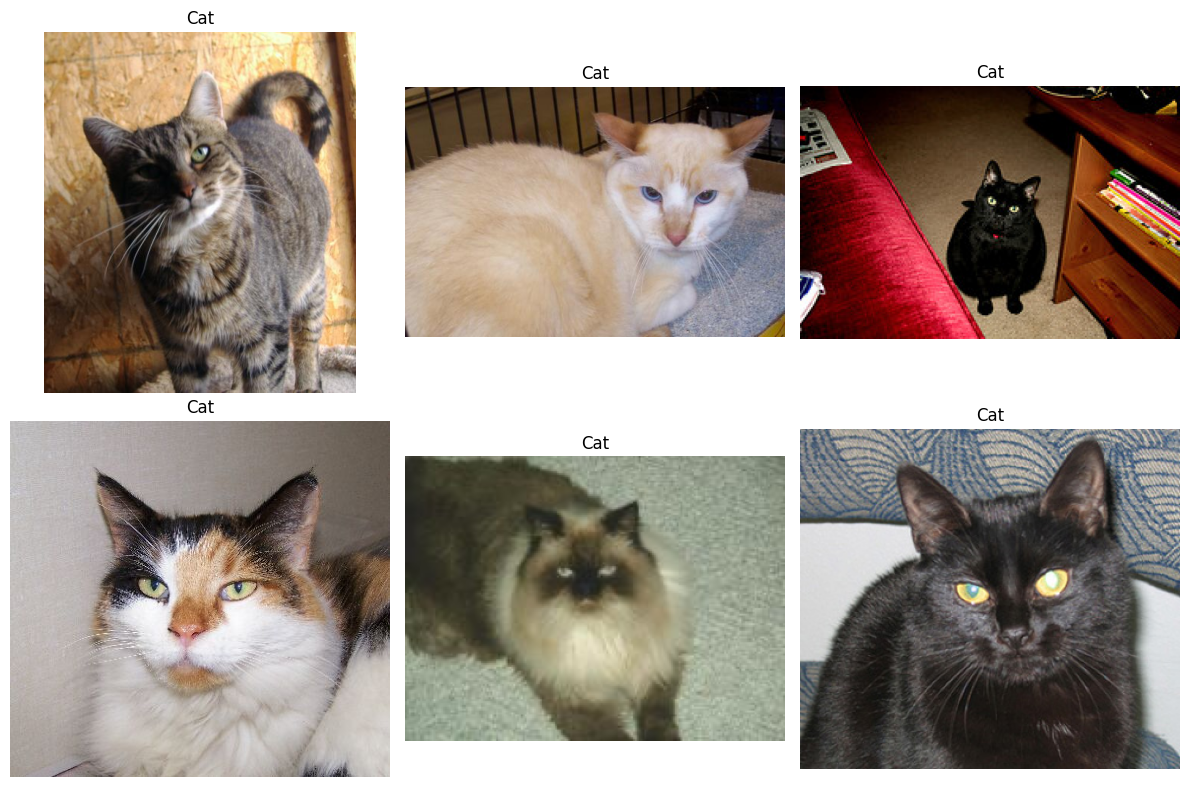

In [10]:
# Display some sample Cat images

plt.figure(figsize=(12, 8))

for i in range(6):

    # Select a random Cat image
    image_name = random.choice(cat_images)

    image_path = os.path.join(cat_path, image_name)

    try:
        image = Image.open(image_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title("Cat")
        plt.axis("off")

    except:
        pass

plt.tight_layout()
plt.show()

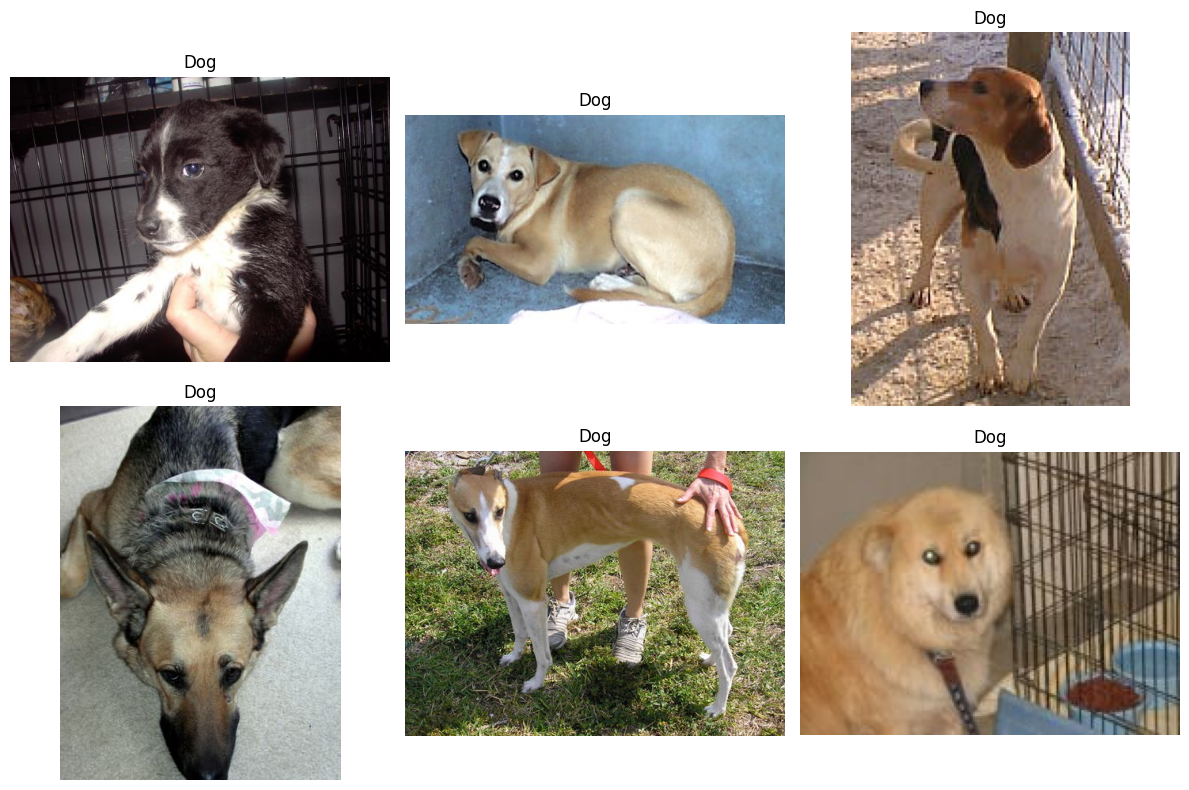

In [11]:
# Display some sample Dog images

plt.figure(figsize=(12, 8))

for i in range(6):

    # Select a random Dog image
    image_name = random.choice(dog_images)

    image_path = os.path.join(dog_path, image_name)

    try:
        image = Image.open(image_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title("Dog")
        plt.axis("off")

    except:
        pass

plt.tight_layout()
plt.show()

In [12]:
# Create class distribution table

class_distribution = pd.DataFrame({
    "Class": ["Cat", "Dog"],
    "Number of Images": [len(cat_images), len(dog_images)]
})

class_distribution

,Class,Number of Images
0,Cat,12491
1,Dog,12470


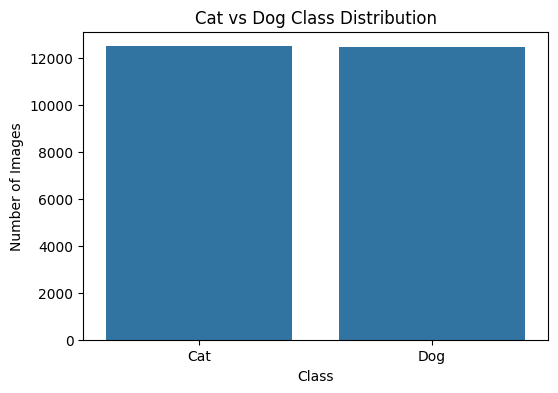

In [13]:
# Display class distribution

plt.figure(figsize=(6, 4))

sns.barplot(
    x="Class",
    y="Number of Images",
    data=class_distribution
)

plt.title("Cat vs Dog Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [14]:
# Check the size of some Cat images

for image_name in cat_images[:10]:

    image_path = os.path.join(cat_path, image_name)

    try:
        image = Image.open(image_path)
        print(image_name, "->", image.size)

    except:
        print(image_name, "-> Cannot open")

11836.jpg -> (250, 241)
3631.jpg -> (350, 295)
12373.jpg -> (500, 413)
6246.jpg -> (357, 500)
11308.jpg -> (403, 500)
5987.jpg -> (500, 375)
11455.jpg -> (500, 254)
1531.jpg -> (500, 375)
11131.jpg -> (500, 375)
11116.jpg -> (500, 375)


In [15]:
# Function to find corrupted images

def find_corrupted_images(folder_path):

    corrupted_images = []

    # Get all files
    files = os.listdir(folder_path)

    for file_name in files:

        file_path = os.path.join(folder_path, file_name)

        try:
            # Open the image
            image = Image.open(file_path)

            # Check whether the image is actually valid
            image.verify()

        except:
            # Add corrupted file to the list
            corrupted_images.append(file_path)

    return corrupted_images

In [16]:
# Check Cat images

corrupted_cats = find_corrupted_images(cat_path)

# Check Dog images

corrupted_dogs = find_corrupted_images(dog_path)

print("Corrupted Cat images:", len(corrupted_cats))
print("Corrupted Dog images:", len(corrupted_dogs))

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Cat images: 1
Corrupted Dog images: 1


In [17]:
# Remove corrupted Cat images

for image_path in corrupted_cats:
    os.remove(image_path)

# Remove corrupted Dog images

for image_path in corrupted_dogs:
    os.remove(image_path)

print("Corrupted images removed successfully.")

Corrupted images removed successfully.


In [18]:
cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Cat images after cleaning:", len(cat_images))
print("Dog images after cleaning:", len(dog_images))

Cat images after cleaning: 12490
Dog images after cleaning: 12469


In [19]:
# Check images and find images that are not RGB, grayscale, or RGBA

def find_invalid_channel_images(folder_path):

    invalid_images = []

    # Get all files in the folder
    files = os.listdir(folder_path)

    for file_name in files:

        file_path = os.path.join(folder_path, file_name)

        try:
            # Open the image
            image = Image.open(file_path)

            # Get the image mode
            mode = image.mode

            # Accept only RGB, L (grayscale), or RGBA images
            if mode not in ["RGB", "L", "RGBA"]:
                invalid_images.append(file_path)

        except:
            # If image cannot be opened
            invalid_images.append(file_path)

    return invalid_images

In [20]:
# Check Cat images

invalid_cats = find_invalid_channel_images(cat_path)

# Check Dog images

invalid_dogs = find_invalid_channel_images(dog_path)

print("Invalid Cat images:", len(invalid_cats))
print("Invalid Dog images:", len(invalid_dogs))

Invalid Cat images: 25
Invalid Dog images: 29


In [21]:
# Display the invalid image paths

print("Invalid Cat images:")
for image_path in invalid_cats:
    print(image_path)

print("\nInvalid Dog images:")
for image_path in invalid_dogs:
    print(image_path)

Invalid Cat images:
/content/kagglecatsanddogs_3367a/PetImages/Cat/10501.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/2663.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/9565.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/5553.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/10820.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/3491.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/850.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/11095.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/936.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/11210.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/9778.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/10125.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/660.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/5370.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/7978.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/3300.jpg
/content/kagglecatsanddogs_3367a/PetImages/Cat/11935.jpg
/content/kagglecatsanddog

In [22]:
# Remove invalid Cat images

for image_path in invalid_cats:
    os.remove(image_path)

# Remove invalid Dog images

for image_path in invalid_dogs:
    os.remove(image_path)

print("Invalid images removed successfully.")

Invalid images removed successfully.


In [23]:
# Count images after cleaning

cat_images = os.listdir(cat_path)
dog_images = os.listdir(dog_path)

print("Cat images:", len(cat_images))
print("Dog images:", len(dog_images))

Cat images: 12465
Dog images: 12440


Step 2: Data Preprocessing

✓ Resize images to 224 × 224
✓ Normalize pixel values 0–255 → 0–1
✓ Rotation
✓ Horizontal Flip
✓ Zoom
✓ Width Shift
✓ Height Shift
✓ Train = 70%
✓ Validation = 15%
✓ Test = 15%

In [24]:
# Image height
IMAGE_HEIGHT = 224

# Image width
IMAGE_WIDTH = 224

# Number of images processed at one time
BATCH_SIZE = 32

print("Image size:", IMAGE_HEIGHT, "x", IMAGE_WIDTH)
print("Batch size:", BATCH_SIZE)

Image size: 224 x 224
Batch size: 32


In [25]:
# Dataset path

dataset_path = "/content/kagglecatsanddogs_3367a/PetImages"

print(dataset_path)

/content/kagglecatsanddogs_3367a/PetImages


In [26]:
# Load 70% of the dataset for training

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="training",
    seed=42
)

print("Training dataset loaded successfully.")

Found 24905 files belonging to 2 classes.
Using 17434 files for training.
Training dataset loaded successfully.


In [27]:
# Load the remaining 30% of the dataset

validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="validation",
    seed=42
)

print("Validation/Test dataset loaded successfully.")

Found 24905 files belonging to 2 classes.
Using 7471 files for validation.
Validation/Test dataset loaded successfully.


In [28]:
# Count the number of batches in the temporary dataset

total_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

print("Total batches:", total_batches)

Total batches: 234


In [29]:
# Calculate half of the batches

half_batches = total_batches // 2

print("Half batches:", half_batches)

Half batches: 117


In [30]:
# First half = validation dataset

validation_dataset = validation_test_dataset.take(half_batches)

print("Validation dataset created.")

Validation dataset created.


In [31]:
# Second half = test dataset

test_dataset = validation_test_dataset.skip(half_batches)

print("Test dataset created.")

Test dataset created.


In [32]:
print("Training batches:",
      tf.data.experimental.cardinality(train_dataset).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(validation_dataset).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 545
Validation batches: 117
Test batches: 117


In [33]:
# Display the class names

class_names = train_dataset.class_names

print("Classes:", class_names)

Classes: ['Cat', 'Dog']


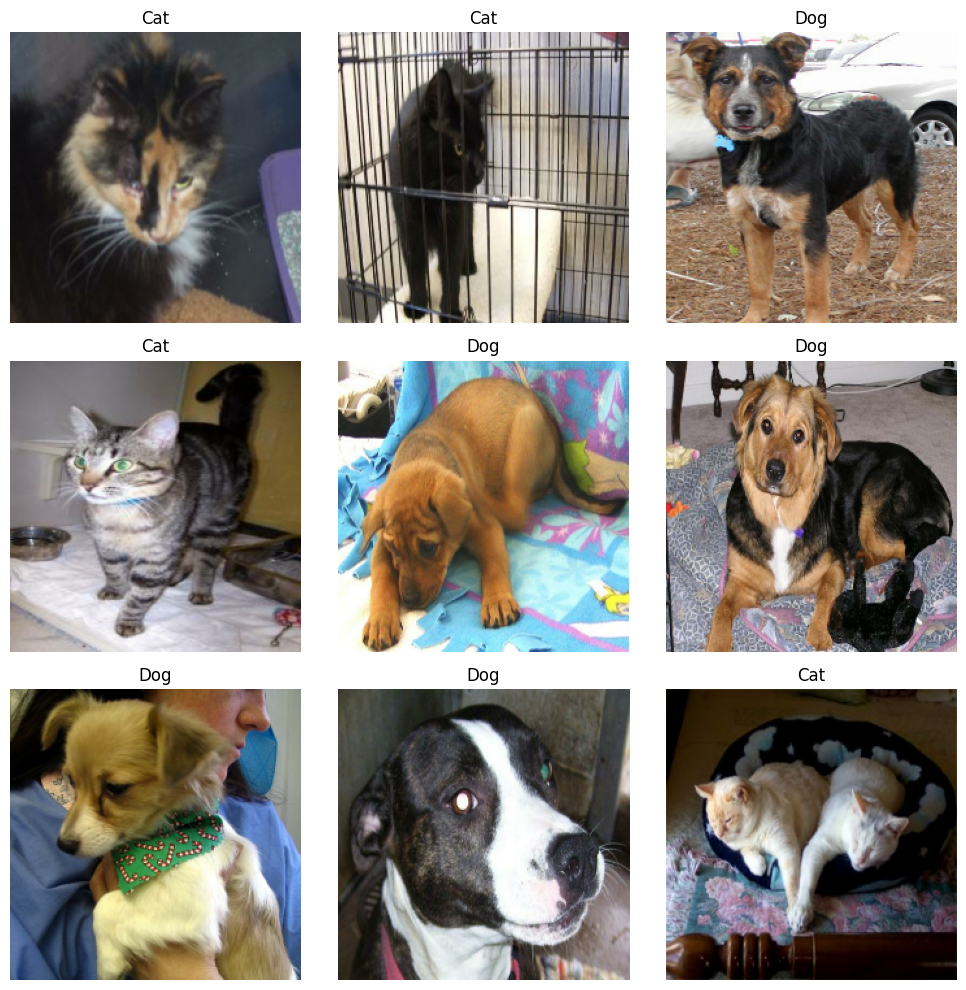

In [34]:
# Display some images from the training dataset

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        # Display image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get the class name
        label = int(labels[i].numpy()[0])

        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Check the shape of one batch of images

for images, labels in train_dataset.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32, 1)


Normalize Pixel Values

In [36]:
# Create a normalization layer

normalization_layer = layers.Rescaling(
    1.0 / 255
)

In [37]:
# Take one batch of images

for images, labels in train_dataset.take(1):

    # Normalize the images
    normalized_images = normalization_layer(images)

    print("Original minimum:", tf.reduce_min(images).numpy())
    print("Original maximum:", tf.reduce_max(images).numpy())

    print("Normalized minimum:", tf.reduce_min(normalized_images).numpy())
    print("Normalized maximum:", tf.reduce_max(normalized_images).numpy())

Original minimum: 0.0
Original maximum: 255.0
Normalized minimum: 0.0
Normalized maximum: 1.0


#Data Augmentation
Rotation\
Horizontal Flip\
Zoom\
Width Shift\
Height Shift\

RandomRotation
       ↓
Rotates the image slightly

RandomFlip
       ↓
Flips image left ↔ right

RandomZoom
       ↓
Zooms in/out slightly

RandomTranslation width
       ↓
Moves image left/right

RandomTranslation height
       ↓
Moves image up/down

In [38]:
# Import Sequential model from Keras

from tensorflow.keras.models import Sequential

In [39]:
# Create data augmentation

data_augmentation = Sequential([

    # Randomly rotate the image
    layers.RandomRotation(0.1),

    # Flip image horizontally
    layers.RandomFlip("horizontal"),

    # Random zoom
    layers.RandomZoom(0.1),

    # Randomly move image horizontally
    layers.RandomTranslation(
        height_factor=0.0,
        width_factor=0.1
    ),

    # Randomly move image vertically
    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.0
    )
])

print("Data augmentation created successfully.")

Data augmentation created successfully.


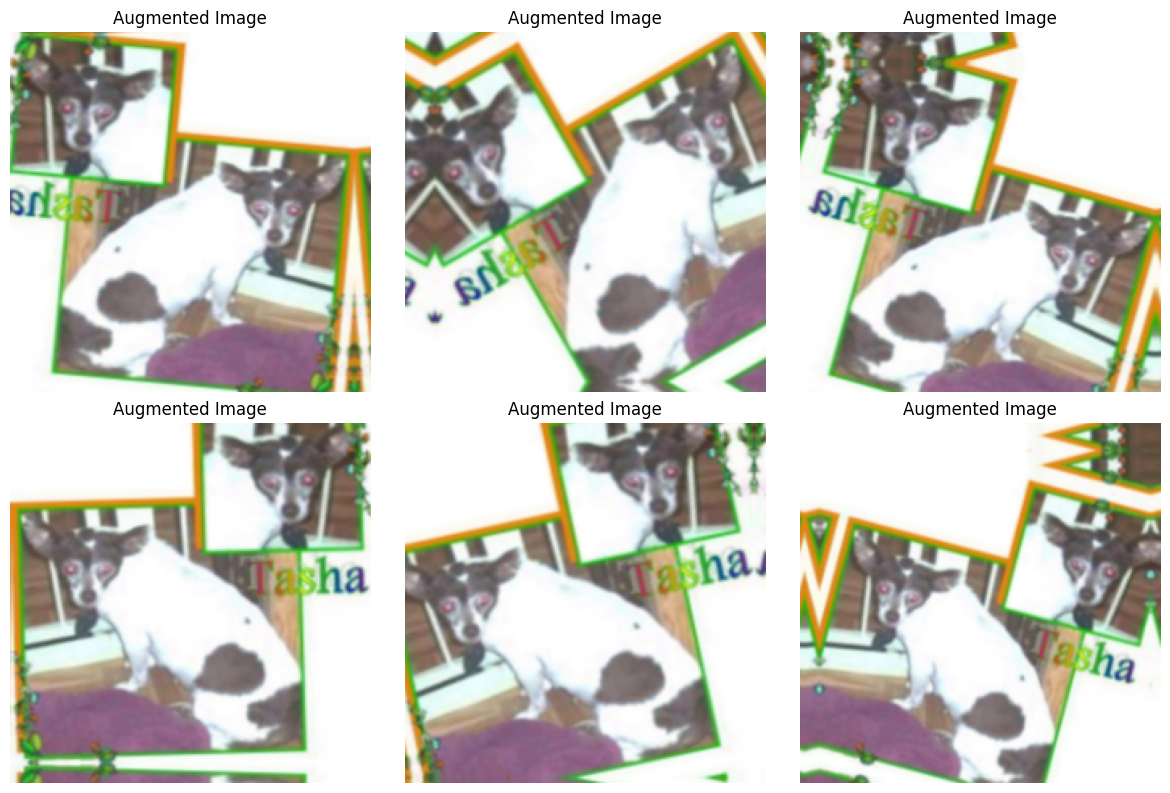

In [40]:
# Get one batch of images

for images, labels in train_dataset.take(1):

    # Select one image
    sample_image = images[0]

    plt.figure(figsize=(12, 8))

    for i in range(6):

        # Apply augmentation
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )

        plt.subplot(2, 3, i + 1)

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.title("Augmented Image")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
# Improve dataset performance

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset preparation completed.")

Dataset preparation completed.


MODEL DEVELOPMENT

In [42]:
print(class_names)

['Cat', 'Dog']


#CUSTOM CNN
Conv2D\
ReLU\
MaxPooling\
Conv2D\
MaxPooling\
Flatten\
Dense\
Dropout\
Sigmoid Output

Input Image
224 × 224 × 3
       ↓
Data Augmentation
       ↓
Normalization
       ↓
Conv2D + ReLU
       ↓
MaxPooling
       ↓
Conv2D + ReLU
       ↓
MaxPooling
       ↓
Flatten
       ↓
Dense
       ↓
Dropout
       ↓
Sigmoid
       ↓
Cat / Dog

In [43]:
# Create Custom CNN model

custom_cnn = Sequential([

    # Data augmentation
    data_augmentation,

    # Normalize pixel values from 0-255 to 0-1
    normalization_layer,

    # First convolution layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    ),

    # Reduce image size
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Second convolution layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce image size again
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps into one-dimensional data
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout helps reduce overfitting
    layers.Dropout(0.5),

    # Output layer
    # 1 means binary classification: Cat or Dog
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

print("Custom CNN created successfully.")

Custom CNN created successfully.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# Display the structure of the CNN

custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 186624)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Compile the Custom CNN

custom_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN compiled successfully.")

Custom CNN compiled successfully.


In [46]:
# Import EarlyStopping

from tensorflow.keras.callbacks import EarlyStopping

In [47]:
# Create EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [48]:
# Check and clean all Cat and Dog images

from PIL import Image
import os

def clean_images(folder_path):

    # Count removed images
    removed_count = 0

    # Get all files in the folder
    files = os.listdir(folder_path)

    for file_name in files:

        file_path = os.path.join(folder_path, file_name)

        try:
            # Open the image
            image = Image.open(file_path)

            # Load the complete image
            image.load()

            # Convert every valid image to RGB
            image = image.convert("RGB")

            # Save it back as a normal RGB JPEG
            image.save(
                file_path,
                format="JPEG"
            )

        except Exception as error:

            # If the image cannot be processed, remove it
            print("Removing:", file_name)
            print("Reason:", error)

            os.remove(file_path)

            removed_count = removed_count + 1

    return removed_count


# Clean Cat images
removed_cats = clean_images(cat_path)

# Clean Dog images
removed_dogs = clean_images(dog_path)

print("Cleaning completed.")
print("Removed Cat images:", removed_cats)
print("Removed Dog images:", removed_dogs)

Cleaning completed.
Removed Cat images: 0
Removed Dog images: 0


In [49]:
print("Checking training dataset...")

batch_number = 0

try:
    for images, labels in train_dataset:
        batch_number += 1

        if images.shape[-1] != 3:
            print("Problem found!")
            print("Batch:", batch_number)
            print("Image shape:", images.shape)
            break
    else:
        print("All training images are valid.")
        print("Total batches checked:", batch_number)

except Exception as error:
    print("ERROR FOUND")
    print("Batch:", batch_number)
    print(error)

Checking training dataset...
All training images are valid.
Total batches checked: 545


In [50]:
print("Checking validation dataset...")

batch_number = 0

try:
    for images, labels in validation_dataset:
        batch_number += 1

        if images.shape[-1] != 3:
            print("Problem found!")
            print("Batch:", batch_number)
            print("Image shape:", images.shape)
            break
    else:
        print("All validation images are valid.")
        print("Total batches checked:", batch_number)

except Exception as error:
    print("ERROR FOUND")
    print("Batch:", batch_number)
    print(error)

Checking validation dataset...
All validation images are valid.
Total batches checked: 117


In [52]:
history_cnn = custom_cnn.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 44s 69ms/step - accuracy: 0.6084 - loss: 0.7027 - val_accuracy: 0.6902 - val_loss: 0.6065
Epoch 2/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 42s 78ms/step - accuracy: 0.6714 - loss: 0.6148 - val_accuracy: 0.7059 - val_loss: 0.5688
Epoch 3/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.6874 - loss: 0.5967 - val_accuracy: 0.7471 - val_loss: 0.5261
Epoch 4/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7013 - loss: 0.5750 - val_accuracy: 0.7529 - val_loss: 0.5303
Epoch 5/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.7223 - loss: 0.5526 - val_accuracy: 0.7564 - val_loss: 0.4988
Epoch 6/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 38s 69ms/step - accuracy: 0.7329 - loss: 0.5350 - val_accuracy: 0.7626 - val_loss: 0.4992
Epoch 7/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.7355 - loss: 0.5277 - val_accuracy: 0.7719 - val_loss: 0.4798
Epoch 8/30
545/545 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.7430 - loss: 0.5227 - 

Plot Training and Validation Accuracy

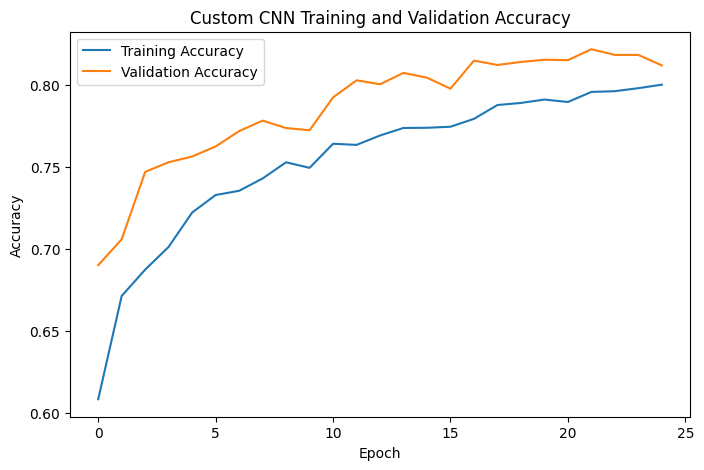

In [53]:
# Get accuracy values from training history

training_accuracy = history_cnn.history["accuracy"]
validation_accuracy = history_cnn.history["val_accuracy"]

# Create graph

plt.figure(figsize=(8, 5))

plt.plot(
    training_accuracy,
    label="Training Accuracy"
)

plt.plot(
    validation_accuracy,
    label="Validation Accuracy"
)

plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

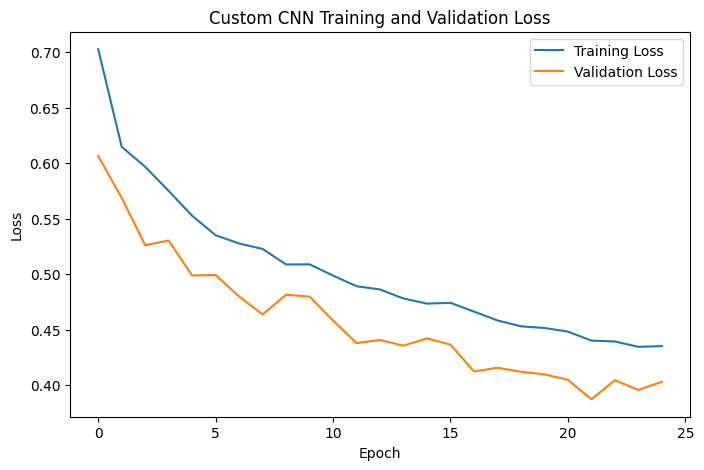

In [54]:
# Get loss values

training_loss = history_cnn.history["loss"]
validation_loss = history_cnn.history["val_loss"]

# Create loss graph

plt.figure(figsize=(8, 5))

plt.plot(
    training_loss,
    label="Training Loss"
)

plt.plot(
    validation_loss,
    label="Validation Loss"
)

plt.title("Custom CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [55]:
# Evaluate Custom CNN on the test dataset

test_loss, test_accuracy = custom_cnn.evaluate(
    test_dataset
)

print("Custom CNN Test Loss:", test_loss)
print("Custom CNN Test Accuracy:", test_accuracy)

117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8165 - loss: 0.4039
Custom CNN Test Loss: 0.40387216210365295
Custom CNN Test Accuracy: 0.8164743781089783


Get Predictions

Now we need predictions for:

Precision
Recall
F1 Score
Confusion Matrix
Classification Report

In [56]:
# Store actual labels and predictions

actual_labels = []
predicted_labels = []

for images, labels in test_dataset:

    # Make predictions
    predictions = custom_cnn.predict(
        images,
        verbose=0
    )

    # Convert probabilities to 0 or 1
    predictions = (predictions >= 0.5).astype(int)

    # Store actual labels
    for label in labels.numpy():
        actual_labels.append(int(label[0]))

    # Store predictions
    for prediction in predictions:
        predicted_labels.append(int(prediction[0]))

Calculate Metrics

In [57]:
# Calculate evaluation metrics

cnn_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

cnn_precision = precision_score(
    actual_labels,
    predicted_labels
)

cnn_recall = recall_score(
    actual_labels,
    predicted_labels
)

cnn_f1 = f1_score(
    actual_labels,
    predicted_labels
)

print("Custom CNN Results")
print("--------------------------")
print("Accuracy :", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall   :", cnn_recall)
print("F1 Score :", cnn_f1)

Custom CNN Results
--------------------------
Accuracy : 0.8183525623826133
Precision: 0.8177521008403361
Recall   : 0.8251192368839427
F1 Score : 0.8214191506198892


In [58]:
# Create confusion matrix

cnn_cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

print(cnn_cm)

[[1493  347]
 [ 330 1557]]


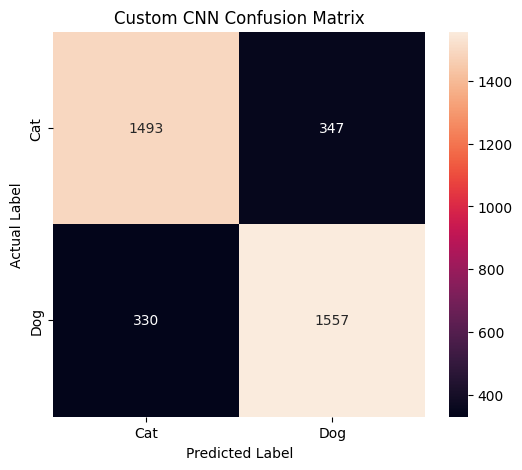

In [59]:
# Display confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Custom CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [60]:
# Display classification report

print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

         Cat       0.82      0.81      0.82      1840
         Dog       0.82      0.83      0.82      1887

    accuracy                           0.82      3727
   macro avg       0.82      0.82      0.82      3727
weighted avg       0.82      0.82      0.82      3727



In [61]:
import os

os.makedirs("model", exist_ok=True)

custom_cnn.save("model/custom_cnn.keras")

print("Custom CNN saved successfully.")

Custom CNN saved successfully.


In [62]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

MobileNetV2 Transfer Learning

In [63]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("MobileNetV2 loaded successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.


In [64]:
base_model.trainable = False

print("Base MobileNetV2 layers are frozen.")

Base MobileNetV2 layers are frozen.


In [65]:
# Create MobileNetV2 transfer learning model

mobilenet_model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    normalization_layer,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

print("MobileNetV2 model created successfully.")

MobileNetV2 model created successfully.


In [66]:
mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [67]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [68]:
early_stopping_mobilenet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping created.")

EarlyStopping created.


In [69]:
history_mobilenet = mobilenet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[early_stopping_mobilenet]
)

Epoch 1/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step - accuracy: 0.9427 - loss: 0.1463 - val_accuracy: 0.9800 - val_loss: 0.0557
Epoch 2/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - accuracy: 0.9586 - loss: 0.1065 - val_accuracy: 0.9797 - val_loss: 0.0511
Epoch 3/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.9612 - loss: 0.1019 - val_accuracy: 0.9818 - val_loss: 0.0478
Epoch 4/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9621 - loss: 0.0957 - val_accuracy: 0.9834 - val_loss: 0.0452
Epoch 5/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.9613 - loss: 0.0966 - val_accuracy: 0.9813 - val_loss: 0.0474
Epoch 6/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - accuracy: 0.9621 - loss: 0.0971 - val_accuracy: 0.9824 - val_loss: 0.0471
Epoch 7/15
545/545 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.9625 - loss: 0.0960 - val_accuracy: 0.9816 - val_loss: 0.0482


In [70]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)

print("MobileNetV2 Test Loss:", test_loss)
print("MobileNetV2 Test Accuracy:", test_accuracy)

117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9828 - loss: 0.0491
MobileNetV2 Test Loss: 0.04911133274435997
MobileNetV2 Test Accuracy: 0.9828280210494995


In [71]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

true_labels = []
predicted_labels = []

for images, labels in test_dataset:

    predictions = mobilenet_model.predict(images, verbose=0)

    predictions = (predictions >= 0.5).astype(int).flatten()
    labels = labels.numpy().astype(int).flatten()

    true_labels.extend(labels)
    predicted_labels.extend(predictions)

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("MobileNetV2 Results")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

MobileNetV2 Results
--------------------------
Accuracy : 0.9822913871746713
Precision: 0.9804336329984136
Recall   : 0.984599044078598
F1 Score : 0.9825119236883942


In [72]:
cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1807   37]
 [  29 1854]]


In [73]:
print("MobileNetV2 Classification Report")
print("----------------------------------")

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["Cat", "Dog"]
    )
)

MobileNetV2 Classification Report
----------------------------------
              precision    recall  f1-score   support

         Cat       0.98      0.98      0.98      1844
         Dog       0.98      0.98      0.98      1883

    accuracy                           0.98      3727
   macro avg       0.98      0.98      0.98      3727
weighted avg       0.98      0.98      0.98      3727



In [74]:
mobilenet_model.save("model/mobilenet_v2_transfer_learning.keras")

print("MobileNetV2 saved successfully.")

MobileNetV2 saved successfully.


Model 3 — Fine-Tuned MobileNetV2

In [75]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

fine_tune_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("Fresh MobileNetV2 loaded.")

Fresh MobileNetV2 loaded.


In [76]:
fine_tune_base.trainable = True

# Freeze most of the MobileNetV2 layers
for layer in fine_tune_base.layers[:-20]:
    layer.trainable = False

print("MobileNetV2 is ready for fine-tuning.")
print("Last 20 layers are trainable.")

MobileNetV2 is ready for fine-tuning.
Last 20 layers are trainable.


In [77]:
trainable_count = 0
non_trainable_count = 0

for layer in fine_tune_base.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        non_trainable_count += 1

print("Trainable layers:", trainable_count)
print("Non-trainable layers:", non_trainable_count)

Trainable layers: 20
Non-trainable layers: 134


In [78]:
fine_tuned_model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    normalization_layer,

    fine_tune_base,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

print("Fine-tuned MobileNetV2 model created.")

Fine-tuned MobileNetV2 model created.


In [79]:
fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuned model compiled.")

Fine-tuned model compiled.


In [80]:
early_stopping_fine_tune = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping created.")

EarlyStopping created.


In [81]:
history_fine_tuned = fine_tuned_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping_fine_tune]
)

Epoch 1/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.8930 - loss: 0.2501 - val_accuracy: 0.9776 - val_loss: 0.0660
Epoch 2/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 76s 89ms/step - accuracy: 0.9488 - loss: 0.1249 - val_accuracy: 0.9840 - val_loss: 0.0479
Epoch 3/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 48s 87ms/step - accuracy: 0.9554 - loss: 0.1098 - val_accuracy: 0.9858 - val_loss: 0.0422
Epoch 4/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 48s 87ms/step - accuracy: 0.9603 - loss: 0.0985 - val_accuracy: 0.9861 - val_loss: 0.0397
Epoch 5/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.9636 - loss: 0.0887 - val_accuracy: 0.9856 - val_loss: 0.0402
Epoch 6/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.9650 - loss: 0.0870 - val_accuracy: 0.9858 - val_loss: 0.0391
Epoch 7/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.9678 - loss: 0.0843 - val_accuracy: 0.9858 - val_loss: 0.0397
Epoch 8/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9694 - loss: 0.0794 - 

Plot Accuracy

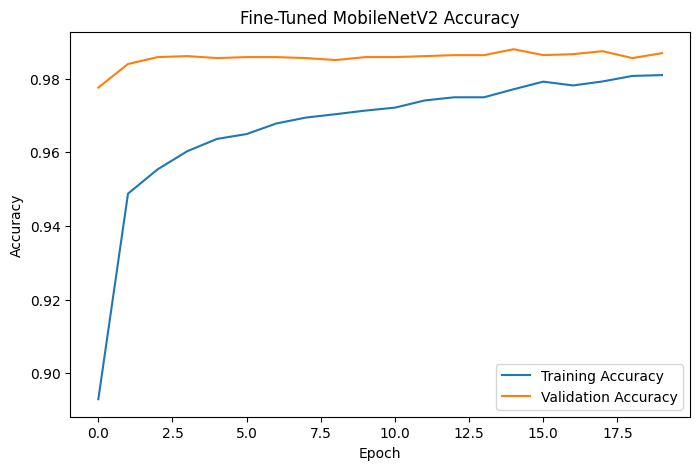

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tuned.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine_tuned.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine-Tuned MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Plot Loss

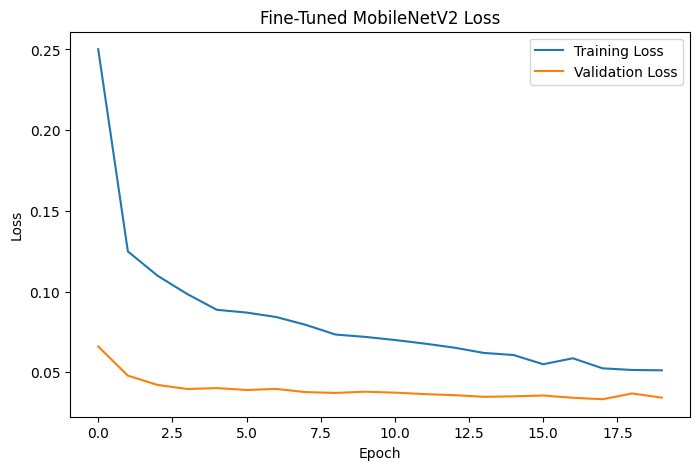

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tuned.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine_tuned.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine-Tuned MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Test the Model

In [84]:
test_loss_fine, test_accuracy_fine = fine_tuned_model.evaluate(
    test_dataset
)

print("Fine-Tuned MobileNetV2 Test Loss:", test_loss_fine)
print("Fine-Tuned MobileNetV2 Test Accuracy:", test_accuracy_fine)

117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9890 - loss: 0.0325
Fine-Tuned MobileNetV2 Test Loss: 0.03246588259935379
Fine-Tuned MobileNetV2 Test Accuracy: 0.9889991879463196


Generate Predictions

In [85]:
true_labels_fine = []
predicted_labels_fine = []

for images, labels in test_dataset:

    predictions = fine_tuned_model.predict(
        images,
        verbose=0
    )

    predictions = (
        predictions >= 0.5
    ).astype(int).flatten()

    labels = labels.numpy().astype(int).flatten()

    true_labels_fine.extend(labels)
    predicted_labels_fine.extend(predictions)

Calculate All Metrics

In [86]:
accuracy_fine = accuracy_score(
    true_labels_fine,
    predicted_labels_fine
)

precision_fine = precision_score(
    true_labels_fine,
    predicted_labels_fine
)

recall_fine = recall_score(
    true_labels_fine,
    predicted_labels_fine
)

f1_fine = f1_score(
    true_labels_fine,
    predicted_labels_fine
)

print("Fine-Tuned MobileNetV2 Results")
print("--------------------------------")
print("Accuracy :", accuracy_fine)
print("Precision:", precision_fine)
print("Recall   :", recall_fine)
print("F1 Score :", f1_fine)

Fine-Tuned MobileNetV2 Results
--------------------------------
Accuracy : 0.9889991950630534
Precision: 0.9862361037586025
Recall   : 0.9920127795527156
F1 Score : 0.9891160074329706


Confusion Matrix

In [87]:
cm_fine = confusion_matrix(
    true_labels_fine,
    predicted_labels_fine
)

print("Fine-Tuned MobileNetV2 Confusion Matrix:")
print(cm_fine)

Fine-Tuned MobileNetV2 Confusion Matrix:
[[1823   26]
 [  15 1863]]


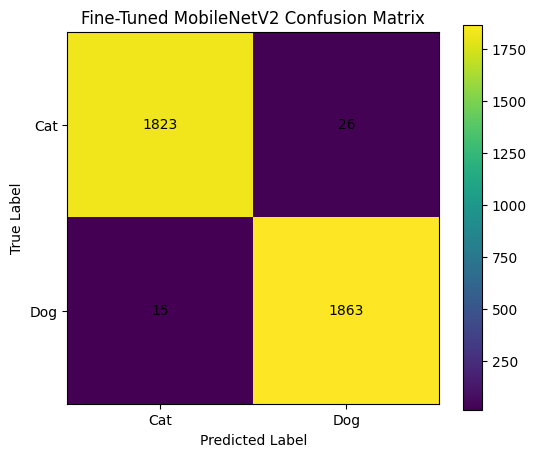

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm_fine)

plt.title("Fine-Tuned MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])

# Display numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_fine[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

Classification Report

In [89]:
print("Fine-Tuned MobileNetV2 Classification Report")
print("---------------------------------------------")

print(
    classification_report(
        true_labels_fine,
        predicted_labels_fine,
        target_names=["Cat", "Dog"]
    )
)

Fine-Tuned MobileNetV2 Classification Report
---------------------------------------------
              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      1849
         Dog       0.99      0.99      0.99      1878

    accuracy                           0.99      3727
   macro avg       0.99      0.99      0.99      3727
weighted avg       0.99      0.99      0.99      3727



Save Model 3

In [90]:
import os

os.makedirs("model", exist_ok=True)

fine_tuned_model.save(
    "model/fine_tuned_mobilenet_v2.keras"
)

print("Fine-tuned MobileNetV2 saved successfully.")

Fine-tuned MobileNetV2 saved successfully.


comparison model

In [97]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "Fine-Tuned MobileNetV2"
    ],

    "Accuracy": [
        0.818353,
        0.982291,
        0.988999
    ],

    "Precision": [
        0.817752,
        0.980434,
        0.986236
    ],

    "Recall": [
        0.825119,
        0.984599,
        0.992013
    ],

    "F1-Score": [
        0.821419,
        0.982512,
        0.989116
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.818353,0.817752,0.825119,0.821419
1,MobileNetV2,0.982291,0.980434,0.984599,0.982512
2,Fine-Tuned MobileNetV2,0.988999,0.986236,0.992013,0.989116


Hyperparameter Tuning

Learning Rate

In [96]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2

def create_model(learning_rate):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Fine-tuning: last 20 layers trainable
    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        normalization_layer,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [99]:
learning_rates = [0.001, 0.0001, 0.00001]

learning_rate_results = []

for lr in learning_rates:

    print("Testing learning rate:", lr)

    model = create_model(lr)

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    learning_rate_results.append({
        "Learning Rate": lr,
        "Best Validation Accuracy": best_val_accuracy
    })

learning_rate_results

Testing learning rate: 0.001
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9523 - loss: 0.1210 - val_accuracy: 0.9837 - val_loss: 0.1406
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.9700 - loss: 0.0784 - val_accuracy: 0.8761 - val_loss: 0.8978
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9718 - loss: 0.0741 - val_accuracy: 0.9762 - val_loss: 0.1268
Testing learning rate: 0.0001
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 68s 110ms/step - accuracy: 0.9508 - loss: 0.1216 - val_accuracy: 0.9696 - val_loss: 0.1185
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9683 - loss: 0.0791 - val_accuracy: 0.9834 - val_loss: 0.0604
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9750 - loss: 0.0627 - val_accuracy: 0.9821 - val_loss: 0.0734
Testing learning rate: 1e-05
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9022 - loss: 0.2335 - val_accuracy: 0.9829 - val_loss: 0.0550
Epoch 2/

[{'Learning Rate': 0.001, 'Best Validation Accuracy': 0.9837072491645813},
 {'Learning Rate': 0.0001, 'Best Validation Accuracy': 0.9834401607513428},
 {'Learning Rate': 1e-05, 'Best Validation Accuracy': 0.9853098392486572}]

In [100]:
learning_rate_table = pd.DataFrame(learning_rate_results)

learning_rate_table

,Learning Rate,Best Validation Accuracy
0,0.00100,0.983707
1,0.00010,0.983440
2,0.00001,0.985310


Optimizer Tuning

In [101]:
def create_optimizer_model(optimizer):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        normalization_layer,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

Adam vs RMSprop Test

In [102]:
optimizers = {
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.0001),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.0001)
}

optimizer_results = []

for name, optimizer in optimizers.items():

    print("Testing optimizer:", name)

    model = create_optimizer_model(optimizer)

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    optimizer_results.append({
        "Optimizer": name,
        "Best Validation Accuracy": best_val_accuracy
    })

optimizer_results

Testing optimizer: Adam
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9515 - loss: 0.1181 - val_accuracy: 0.9810 - val_loss: 0.0825
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.9676 - loss: 0.0802 - val_accuracy: 0.9802 - val_loss: 0.0859
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.9755 - loss: 0.0631 - val_accuracy: 0.9661 - val_loss: 0.1522
Testing optimizer: RMSprop
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.9498 - loss: 0.1246 - val_accuracy: 0.9848 - val_loss: 0.0607
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.9681 - loss: 0.0825 - val_accuracy: 0.9816 - val_loss: 0.0934
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 91ms/step - accuracy: 0.9754 - loss: 0.0631 - val_accuracy: 0.9829 - val_loss: 0.1143


[{'Optimizer': 'Adam', 'Best Validation Accuracy': 0.9810363054275513},
 {'Optimizer': 'RMSprop', 'Best Validation Accuracy': 0.9847756624221802}]

In [103]:
optimizer_table = pd.DataFrame(optimizer_results)

optimizer_table

,Optimizer,Best Validation Accuracy
0,Adam,0.981036
1,RMSprop,0.984776


Dropout Tuning

In [104]:
def create_dropout_model(dropout):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        normalization_layer,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(
            learning_rate=0.0001
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [105]:
dropout_values = [0.2, 0.3, 0.5]

dropout_results = []

for dropout in dropout_values:

    print("Testing dropout:", dropout)

    model = create_dropout_model(dropout)

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    dropout_results.append({
        "Dropout": dropout,
        "Best Validation Accuracy": best_val_accuracy
    })

dropout_results

Testing dropout: 0.2
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.9530 - loss: 0.1167 - val_accuracy: 0.9834 - val_loss: 0.0661
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.9666 - loss: 0.0854 - val_accuracy: 0.9837 - val_loss: 0.0710
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.9729 - loss: 0.0711 - val_accuracy: 0.9818 - val_loss: 0.1039
Testing dropout: 0.3
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9535 - loss: 0.1185 - val_accuracy: 0.9832 - val_loss: 0.0667
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.9686 - loss: 0.0808 - val_accuracy: 0.9647 - val_loss: 0.1871
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 50s 91ms/step - accuracy: 0.9753 - loss: 0.0651 - val_accuracy: 0.9300 - val_loss: 0.4727
Testing dropout: 0.5
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.9480 - loss: 0.1254 - val_accuracy: 0.9749 - val_loss: 0.1124
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━

[{'Dropout': 0.2, 'Best Validation Accuracy': 0.9837072491645813},
 {'Dropout': 0.3, 'Best Validation Accuracy': 0.9831730723381042},
 {'Dropout': 0.5, 'Best Validation Accuracy': 0.9748931527137756}]

In [106]:
dropout_table = pd.DataFrame(dropout_results)

dropout_table

,Dropout,Best Validation Accuracy
0,0.2,0.983707
1,0.3,0.983173
2,0.5,0.974893


Number of Trainable Layers

Model Function

In [107]:
def create_layers_model(trainable_layers):

    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = True

    for layer in base.layers[:-trainable_layers]:
        layer.trainable = False

    model = Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        normalization_layer,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(
            learning_rate=0.0001
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

Test 10, 20, 30 Layers

In [108]:
trainable_layers_values = [10, 20, 30]

trainable_layers_results = []

for n in trainable_layers_values:

    print("Testing trainable layers:", n)

    model = create_layers_model(n)

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=3,
        verbose=1
    )

    best_val_accuracy = max(history.history["val_accuracy"])

    trainable_layers_results.append({
        "Trainable Layers": n,
        "Best Validation Accuracy": best_val_accuracy
    })

trainable_layers_results

Testing trainable layers: 10
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 51s 83ms/step - accuracy: 0.9440 - loss: 0.1360 - val_accuracy: 0.9826 - val_loss: 0.0536
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 45s 81ms/step - accuracy: 0.9600 - loss: 0.1003 - val_accuracy: 0.9840 - val_loss: 0.0477
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.9635 - loss: 0.0890 - val_accuracy: 0.9842 - val_loss: 0.0475
Testing trainable layers: 20
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.9510 - loss: 0.1219 - val_accuracy: 0.9840 - val_loss: 0.0713
Epoch 2/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.9668 - loss: 0.0867 - val_accuracy: 0.9832 - val_loss: 0.1177
Epoch 3/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 82s 85ms/step - accuracy: 0.9740 - loss: 0.0694 - val_accuracy: 0.9816 - val_loss: 0.1268
Testing trainable layers: 30
Epoch 1/3
545/545 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.9507 - loss: 0.1226 - val_accuracy: 0.9800 - val_loss: 0.1010
Epoch 2/3


[{'Trainable Layers': 10, 'Best Validation Accuracy': 0.9842414259910583},
 {'Trainable Layers': 20, 'Best Validation Accuracy': 0.9839743375778198},
 {'Trainable Layers': 30, 'Best Validation Accuracy': 0.9853098392486572}]

In [109]:
trainable_layers_table = pd.DataFrame(
    trainable_layers_results
)

trainable_layers_table

,Trainable Layers,Best Validation Accuracy
0,10,0.984241
1,20,0.983974
2,30,0.985310


Final Model Training

In [110]:
final_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

final_base.trainable = True

for layer in final_base.layers[:-30]:
    layer.trainable = False

final_model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    normalization_layer,
    final_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer=tf.keras.optimizers.RMSprop(
        learning_rate=0.00001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [111]:
early_stopping_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [112]:
history_final = final_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping_final]
)

Epoch 1/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 60s 94ms/step - accuracy: 0.9048 - loss: 0.2284 - val_accuracy: 0.9821 - val_loss: 0.0512
Epoch 2/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.9539 - loss: 0.1127 - val_accuracy: 0.9842 - val_loss: 0.0426
Epoch 3/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9584 - loss: 0.1034 - val_accuracy: 0.9816 - val_loss: 0.0437
Epoch 4/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9649 - loss: 0.0893 - val_accuracy: 0.9832 - val_loss: 0.0404
Epoch 5/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 52s 96ms/step - accuracy: 0.9664 - loss: 0.0838 - val_accuracy: 0.9842 - val_loss: 0.0386
Epoch 6/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9717 - loss: 0.0734 - val_accuracy: 0.9861 - val_loss: 0.0384
Epoch 7/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - accuracy: 0.9717 - loss: 0.0722 - val_accuracy: 0.9864 - val_loss: 0.0372
Epoch 8/20
545/545 ━━━━━━━━━━━━━━━━━━━━ 49s 89ms/step - accuracy: 0.9720 - loss: 0.0713 - 

In [114]:
test_loss, test_accuracy = final_model.evaluate(test_dataset)

print("Final Model Test Loss:", test_loss)
print("Final Model Test Accuracy:", test_accuracy)

117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.9882 - loss: 0.0351
Final Model Test Loss: 0.035113174468278885
Final Model Test Accuracy: 0.9881942868232727


In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = final_model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int).flatten()

    y_pred.extend(predictions)
    y_true.extend(labels.numpy().astype(int).flatten())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Final Model Results")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

Final Model Results
--------------------------
Accuracy : 0.9881942581164476
Precision: 0.9878242456326098
Recall   : 0.9888712241653418
F1 Score : 0.9883474576271186

Classification Report
              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      1840
         Dog       0.99      0.99      0.99      1887

    accuracy                           0.99      3727
   macro avg       0.99      0.99      0.99      3727
weighted avg       0.99      0.99      0.99      3727



In [116]:
import os

os.makedirs("model", exist_ok=True)

final_model.save("model/cats_dogs_model.keras")

print("Final model saved successfully.")

Final model saved successfully.
